In [3]:
import zipfile
with zipfile.ZipFile('archive.zip','r')as zip_ref:
  zip_ref.extractall('.')

In [6]:
import pandas as pd
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [7]:
# Check dataset shape (rows and columns)
print(df.shape)

# Check info about columns and data types
df.info()


(7043, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null

In [8]:
# Check for missing values in each column
df.isnull().sum()


,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [10]:
# Check unique values or try converting TotalCharges to numeric
print(df['TotalCharges'].dtype)


object


In [12]:
# Convert TotalCharges to numeric, turning blank spaces into NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check if there are any missing values now in TotalCharges
print(df['TotalCharges'].isnull().sum())


11


In [13]:
# Drop the 11 rows where TotalCharges is missing
df = df.dropna(subset=['TotalCharges'])

# Check the new shape of the dataframe
print(df.shape)


(7032, 21)


In [14]:
# Check the count of Churn (Yes vs No)
df['Churn'].value_counts()


,count
Churn,
No,5163
Yes,1869


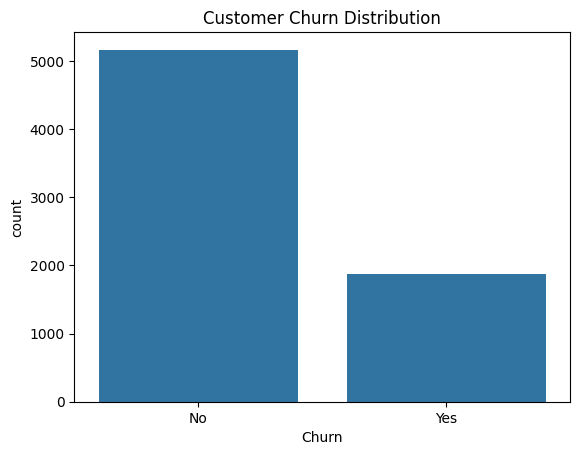

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plotting the customer churn count
sns.countplot(x='Churn', data=df)
plt.title('Customer Churn Distribution')
plt.show()


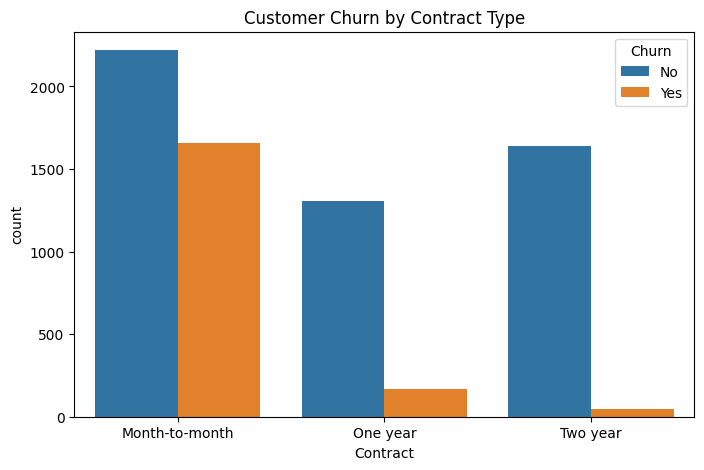

In [16]:
# Check how Contract type affects Churn
plt.figure(figsize=(8, 5))
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title('Customer Churn by Contract Type')
plt.show()



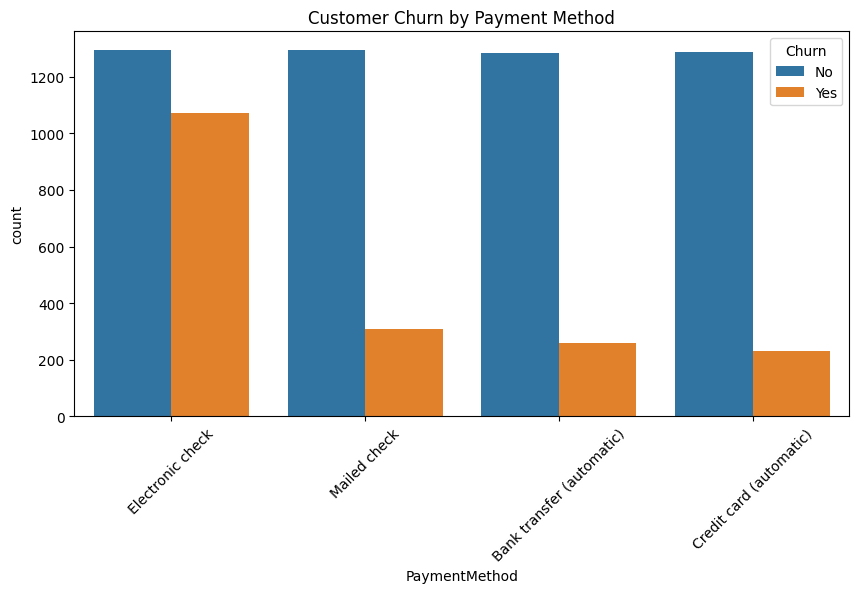

In [17]:
# Check how Payment Method affects Churn
plt.figure(figsize=(10, 5))
sns.countplot(x='PaymentMethod', hue='Churn', data=df)
plt.title('Customer Churn by Payment Method')
plt.xticks(rotation=45)
plt.show()


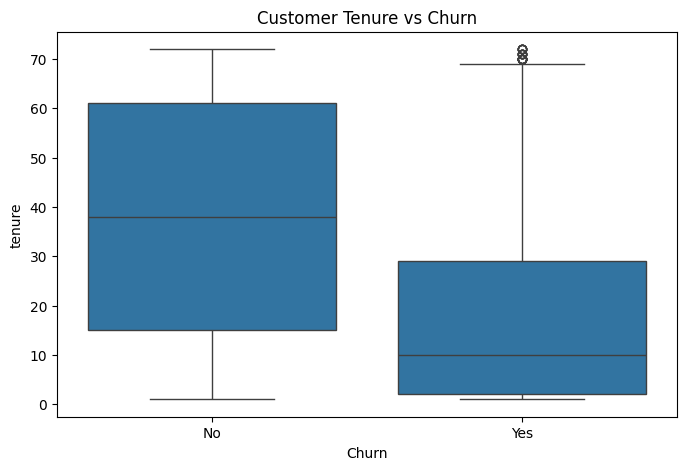

In [18]:
# Check how Tenure affects Churn using a boxplot
plt.figure(figsize=(8, 5))
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title('Customer Tenure vs Churn')
plt.show()


In [19]:
# Convert categorical columns into numeric format using one-hot encoding or mapping
# For Churn, Yes=1 and No=0
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Let's check the first few rows of Churn column to verify
print(df['Churn'].head())


0    0
1    0
2    1
3    0
4    1
Name: Churn, dtype: int64


In [20]:
# Drop customerID as it is a unique identifier and not needed for prediction
if 'customerID' in df.columns:
    df = df.drop('customerID', axis=1)

# Convert all remaining categorical columns into numeric format
df_encoded = pd.get_dummies(df, drop_first=True)

# Check the new shape and columns
print(df_encoded.shape)
print(df_encoded.head(2))


(7032, 31)
   SeniorCitizen  tenure  MonthlyCharges  TotalCharges  Churn  gender_Male  \
0              0       1           29.85         29.85      0        False   
1              0      34           56.95       1889.50      0         True   

   Partner_Yes  Dependents_Yes  PhoneService_Yes  \
0         True           False             False   
1        False           False              True   

   MultipleLines_No phone service  ...  StreamingTV_No internet service  \
0                            True  ...                            False   
1                           False  ...                            False   

   StreamingTV_Yes  StreamingMovies_No internet service  StreamingMovies_Yes  \
0            False                                False                False   
1            False                                False                False   

   Contract_One year  Contract_Two year  PaperlessBilling_Yes  \
0              False              False                  True   


In [21]:
from sklearn.model_selection import train_test_split

# Separate features (X) and target (y)
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

# Split data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)


Training data shape: (5625, 30)
Testing data shape: (1407, 30)


In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Initialize and train the model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Make predictions on the test data
y_pred = model.predict(X_test)

# Check the accuracy score
print("Model Accuracy:", accuracy_score(y_test, y_pred))


Model Accuracy: 0.7874911158493249


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [23]:
from sklearn.metrics import classification_report

# Print detailed classification report
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.52      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



In [24]:
# Initialize Logistic Regression with a higher max_iter to remove the warning
model = LogisticRegression(max_iter=10000)
model.fit(X_train, y_train)

# Re-evaluate
y_pred = model.predict(X_test)
print("Optimized Accuracy:", accuracy_score(y_test, y_pred))


Optimized Accuracy: 0.7882018479033405


In [25]:
import pandas as pd

# Create a dataframe of model coefficients to see top factors driving churn
feature_importances = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

print(feature_importances.head(10))


                           Feature  Coefficient
10     InternetService_Fiber optic     1.077985
23             StreamingMovies_Yes     0.363966
21                 StreamingTV_Yes     0.344132
8   MultipleLines_No phone service     0.340190
9                MultipleLines_Yes     0.282182
26            PaperlessBilling_Yes     0.277857
0                    SeniorCitizen     0.260046
28  PaymentMethod_Electronic check     0.256085
5                      Partner_Yes     0.052228
17            DeviceProtection_Yes     0.039277


In [26]:
import joblib

# Save the trained model to disk
joblib.dump(model, 'churn_model.pkl')
print("Model successfully saved as churn_model.pkl!")


Model successfully saved as churn_model.pkl!
